

## 과제 목적
이번 과제는 수업에서 다룬 **Grain, Cardinality, JOIN, CTE, Window Function, 파생변수**를 실제 Olist 데이터에 직접 적용하는 것을 목표로 합니다. 단순히 SQL이 실행되는지 확인하는 것이 아니라, **결과가 분석적으로 올바른지 직접 검증하고 그 의미를 해석**해야 합니다. 생성형 AI를 사용할 수 있지만, AI가 제안한 쿼리나 해석을 그대로 제출하는 것이 아니라 **본인의 로컬 DB에서 실행 결과를 확인하고, 지표 정의와 JOIN 구조가 타당한지 판단**해야 합니다. 최종적으로 Colab에서 수행한 실험·그래프·해석을 기술블로그에 재구성합니다.

---
> 블로그에는 코드를 그대로 복사하기보다 **왜 이 쿼리를 썼는지 → 어떻게 검증했는지 → 결과를 어떻게 해석했는지**를 중심으로 작성하세요.



# 0. 환경 설정

일반 Colab Hosted Runtime의 `127.0.0.1`은 본인 PC가 아닙니다.  
로컬 MySQL에 접속하려면 **Colab Local Runtime**을 사용하세요.

로컬 터미널/PowerShell에서 Jupyter를 실행한 뒤 Colab의  
**연결 → 로컬 런타임에 연결** 메뉴에 URL을 입력합니다.

```bash
jupyter notebook --NotebookApp.allow_origin='https://colab.research.google.com' --port=8888 --NotebookApp.port_retries=0 --NotebookApp.allow_credentials=True
```


In [28]:
%pip install -q pymysql sqlalchemy pandas matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from getpass import getpass
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
import pandas as pd
import matplotlib.pyplot as plt

DB_HOST = "127.0.0.1"
DB_PORT = 3306
DB_NAME = "olist_sql_session"

DB_USER = input("MySQL 사용자명: ").strip()
DB_PASSWORD = getpass("MySQL 비밀번호: ")

url = URL.create(
    drivername="mysql+pymysql",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME,
    query={"charset": "utf8mb4"},
)

engine = create_engine(url, pool_pre_ping=True)

def run_sql(sql: str) -> pd.DataFrame:
    """SELECT / WITH 쿼리를 실행하고 DataFrame으로 반환합니다."""
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

print("DB 연결 객체 생성 완료")


MySQL 사용자명: root
MySQL 비밀번호: ··········
DB 연결 객체 생성 완료


In [30]:
with engine.connect() as conn:
    info = conn.execute(
        text("SELECT VERSION() AS mysql_version, DATABASE() AS current_db;")
    ).mappings().one()

print(dict(info))
print("✅ 연결 성공")


{'mysql_version': '8.0.45', 'current_db': 'olist_sql_session'}
✅ 연결 성공


In [31]:
run_sql("SHOW TABLES;")


,Tables_in_olist_sql_session
0,olist_customers_dataset
1,olist_geolocation_dataset
2,olist_order_items_dataset
3,olist_order_payments_dataset
4,olist_order_reviews_dataset
5,olist_orders_dataset
6,olist_products_dataset
7,olist_sellers_dataset
8,order_mart
9,product_category_name_translation


# 1. 필수 과제

## 빈칸 작성 방식
- `__BLANK_n__` 부분만 올바른 SQL/Python 코드로 바꾸면 됩니다.
- 빈칸을 채워 실행한 뒤  **결과 검증 + 해석**까지 작성하세요.


## 1.1 Grain과 Cardinality 확인

세 테이블의 **한 행이 무엇을 의미하는지** 확인합니다.

- `olist_orders_dataset`
- `olist_order_items_dataset`
- `olist_order_payments_dataset`

### 목표
- 전체 행 수
- 고유 주문 수
- 한 주문이 여러 행으로 나타나는지 확인


In [32]:
# [1.1-A] orders
# 힌트: 고유 주문 수는 order_id에 DISTINCT를 적용합니다.

orders_grain_sql = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS distinct_orders
FROM olist_orders_dataset;
"""

orders_grain_df = run_sql(orders_grain_sql)
orders_grain_df


,total_rows,distinct_orders
0,99441,99441


In [33]:
# [1.1-B] order_items
# 힌트: 한 주문 안에 여러 상품 행이 있을 수 있습니다.
# 전체 행 수와 고유 order_id 수의 차이를 확인하세요.

items_grain_sql = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS distinct_orders
FROM olist_order_items_dataset;
"""

items_grain_df = run_sql(items_grain_sql)
items_grain_df


,total_rows,distinct_orders
0,112650,98666


In [34]:
# [1.1-C] payments
# 힌트: 한 주문에 결제 행이 여러 개 존재할 수 있습니다.

payments_grain_sql = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS distinct_orders
FROM olist_order_payments_dataset;
"""

payments_grain_df = run_sql(payments_grain_sql)
payments_grain_df


,total_rows,distinct_orders
0,103886,99440


### 1.1 해석
- `orders`의 한 행: 주문 1건을 의미한다.
- `order_items`의 한 행: 주문 내 포함된 개별 상품 1개를 의미한다.
- `payments`의 한 행: 주문 건에 대해 발생한 수단별 결제 1건을 의미한다.
- `orders → order_items` 관계: 한 주문에 여러 상품이 포함될 수 있는 1: N 관계이다.
- `orders → payments` 관계: 한 주문을 복수의 결제 수단으로 지불할 수 있는 일대다 관계이다.
- Grain을 확인하지 않고 JOIN하면 어떤 문제가 생길 수 있는지: 1:N 관계에 있는 테이블들을 GRAIN을 확인하지 않고 JOIN 하면 행이 다중으로 증폭되는 Row Explosion 현상이 발생한다. 이로 인해 SUM 이나 COUNT 등의 집계 연산 수행 시 금액 및 건수가 중복되어 부풀려지는 데이터 오류가 생기게 된다.


---

## 1.2 문법적으로 맞는 JOIN이 왜 잘못된 결과를 만들까?

배송 완료(`delivered`) 주문을 기준으로:
1. 주문 수
2. 상품 판매금액
3. 결제금액

을 먼저 **올바른 기준값**으로 계산한 뒤,  
`orders + order_items + payments`를 한 번에 JOIN한 결과와 비교합니다.


In [35]:
# [1.2-A] 올바른 기준값 계산
#
# 힌트
# - 주문 수: orders 단독
# - 상품 판매금액: orders + order_items만 JOIN
# - 결제금액: orders + payments만 JOIN
# - 세 지표 모두 delivered 주문만 사용
#
# 문자열 delivered는 따옴표를 포함해야 합니다.

correct_metric_sql = """
SELECT
    (
        SELECT COUNT(*)
        FROM olist_orders_dataset
        WHERE order_status = 'delivered'
    ) AS correct_order_count,

    (
        SELECT ROUND(SUM(oi.price), 2)
        FROM olist_orders_dataset AS o
        JOIN olist_order_items_dataset AS oi
          ON o.order_id = oi.order_id
        WHERE o.order_status = 'delivered'
    ) AS correct_item_amount,

    (
        SELECT ROUND(SUM(p.payment_value), 2)
        FROM olist_orders_dataset AS o
        JOIN olist_order_payments_dataset AS p
          ON o.order_id = p.order_id
        WHERE o.order_status = 'delivered'
    ) AS correct_payment_amount;
"""

correct_df = run_sql(correct_metric_sql)
correct_df


,correct_order_count,correct_item_amount,correct_payment_amount
0,96478,13221498.11,15422461.77


In [36]:
# [1.2-B] naive JOIN
#
# 힌트
# - orders ↔ order_items: order_id
# - orders ↔ payments: order_id
# - delivered 주문만 필터링
# - COUNT(*)는 JOIN된 결과 행 수
# - COUNT(DISTINCT o.order_id)는 JOIN 뒤 고유 주문 수

naive_join_sql = """
SELECT
    COUNT(*) AS joined_rows,
    COUNT(DISTINCT o.order_id) AS orders_after_join,
    ROUND(SUM(oi.price), 2) AS wrong_item_amount,
    ROUND(SUM(p.payment_value), 2) AS wrong_payment_amount
FROM olist_orders_dataset AS o
JOIN olist_order_items_dataset AS oi
  ON o.order_id = oi.order_id
JOIN olist_order_payments_dataset AS p
  ON o.order_id = p.order_id
WHERE o.order_status = 'delivered';
"""

naive_df = run_sql(naive_join_sql)
naive_df


,joined_rows,orders_after_join,wrong_item_amount,wrong_payment_amount
0,115035,96477,13813828.71,19776160.44


In [37]:
# [1.2-C] 금액 부풀림 비율
#
# 공식:
# (잘못 계산된 값 / 올바른 기준값 - 1) * 100

correct_item = float(correct_df.loc[0, "correct_item_amount"])
correct_payment = float(correct_df.loc[0, "correct_payment_amount"])
wrong_item = float(naive_df.loc[0, "wrong_item_amount"])
wrong_payment = float(naive_df.loc[0, "wrong_payment_amount"])

item_inflation_pct = (wrong_item / correct_item - 1) * 100
payment_inflation_pct = (wrong_payment / correct_payment - 1) * 100

print(f"상품 판매금액 증가율: {item_inflation_pct:.2f}%")
print(f"결제금액 증가율: {payment_inflation_pct:.2f}%")


상품 판매금액 증가율: 4.48%
결제금액 증가율: 28.23%


### 1.2 해석
1. JOIN 후 행 수가 주문 수보다 증가한 이유는?
- orders 테이블에 order_items와 payments 테이블이 동시 결합되면서 행 수 관계가 1 X N X M 으로 중복 증폭되는 Row Explosion 현상이 발생하였기 때문이다.

2. `COUNT(*)`와 `COUNT(DISTINCT o.order_id)`가 다른 이유는?
- COUNT(*)는 다중 JOIN 으로 인해 뻥튀기된 전체 결과 행 수(115,035건)를 세는 반면, COUNT(DISTINCT o.order_id)는 중복 생성된 행들 속에서 실제 고유한 주문 건수(96,477건)만을 추려내어 집계하기 때문이다.

3. 상품 판매금액과 결제금액 중 어느 쪽이 더 크게 부풀었는가?
- 결제금액 증가율이 28.23% 로, 상품 판매금액 증가율 4.48% 보다 훨씬 더 크게 부풀었다. 이는 복수의 결제 수단 이 결합하면서 결제금액 데이터의 중복 곱셈 조합이 더 많이 발생했기 때문이다.

4. `SELECT DISTINCT`만으로 이 문제를 해결하면 안 되는 이유는?
- SELECT DISTINCT는 완전 중복된 행 전체를 제거할 뿐이며, SUM(oi.price) 나 SUM(p.payment_value) 같은 집계 연산 시 수행되는 내부적인 행 중복 계산 자체를 막아주지는 못하기 때문이다.

5. JOIN 결과의 **한 행**은 무엇을 의미하게 되었는가?
- 단순 주문 1건이 아니라 특정 주문 내의 개별 상품 1개 x 해당 주문의 개별 결제 수단 1건이 조합된 교차 생성 행을 의미하게 되었다.


---

## 1.3 주문 단위 분석 데이터 구성 + 배송 지연과 리뷰 분석

Mission 1의 Row Explosion을 피하기 위해 각 1:N 테이블을 **order_id 단위로 먼저 집계**합니다.

목표 Grain:

> **1 row = 1 order**

### 파생변수
- `delivery_days`: 실제 배송완료일 - 주문일
- `delay_days`: 실제 배송완료일 - 예상 배송일
- `is_delayed`: 실제 배송완료일이 예상 배송일보다 늦으면 1


In [38]:
# [1.3-A] 주문 단위 Mart 만들기
#
# item_summary 힌트
# - product_count: product_id의 고유 개수
# - seller_count: seller_id의 고유 개수
# - item_amount: price 합계
# - freight_amount: freight_value 합계
#
# payment_summary 힌트
# - payment_amount: payment_value 합계
# - max_installments: payment_installments 최대값
#
# review_summary 힌트
# - avg_review_score: review_score 평균
#
# 각 CTE의 GROUP BY 기준은 모두 order_id 입니다.

order_mart_sql = """
WITH item_summary AS (
    SELECT
        order_id,
        COUNT(*) AS item_count,
        COUNT(DISTINCT product_id) AS product_count,
        COUNT(DISTINCT seller_id) AS seller_count,
        SUM(price) AS item_amount,
        SUM(freight_value) AS freight_amount
    FROM olist_order_items_dataset
    GROUP BY order_id
),

payment_summary AS (
    SELECT
        order_id,
        COUNT(*) AS payment_count,
        SUM(payment_value) AS payment_amount,
        MAX(payment_installments) AS max_installments
    FROM olist_order_payments_dataset
    GROUP BY order_id
),

review_summary AS (
    SELECT
        order_id,
        COUNT(*) AS review_count,
        AVG(review_score) AS avg_review_score
    FROM olist_order_reviews_dataset
    GROUP BY order_id
)

SELECT
    o.order_id,
    o.customer_id,
    c.customer_unique_id,
    c.customer_state,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,

    i.item_count,
    i.product_count,
    i.seller_count,
    i.item_amount,
    i.freight_amount,

    p.payment_count,
    p.payment_amount,
    p.max_installments,

    r.review_count,
    r.avg_review_score,

    /* delivery_days = 실제 배송완료일 - 주문일 */
    CASE
        WHEN o.order_delivered_customer_date IS NULL THEN NULL
        ELSE DATEDIFF(
            o.order_delivered_customer_date,
            o.order_purchase_timestamp
        )
    END AS delivery_days,

    /* delay_days = 실제 배송완료일 - 예상 배송일
       양수: 지연 / 0: 예정일 / 음수: 조기 배송 */
    CASE
        WHEN o.order_delivered_customer_date IS NULL
          OR o.order_estimated_delivery_date IS NULL THEN NULL
        ELSE DATEDIFF(
            o.order_delivered_customer_date,
            o.order_estimated_delivery_date
        )
    END AS delay_days,

    /* 실제 배송완료일 > 예상 배송일 이면 1 */
    CASE
        WHEN o.order_delivered_customer_date IS NULL
          OR o.order_estimated_delivery_date IS NULL THEN NULL
        WHEN DATEDIFF(o.order_delivered_customer_date, o.order_estimated_delivery_date) > 0 THEN 1
        ELSE 0
    END AS is_delayed

FROM olist_orders_dataset AS o

LEFT JOIN olist_customers_dataset AS c
  ON o.customer_id = c.customer_id

LEFT JOIN item_summary AS i
  ON o.order_id = i.order_id

LEFT JOIN payment_summary AS p
  ON o.order_id = p.order_id

LEFT JOIN review_summary AS r
  ON o.order_id = r.order_id;
"""

order_mart_df = run_sql(order_mart_sql)
order_mart_df.head()


,order_id,customer_id,customer_unique_id,customer_state,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,item_count,product_count,...,item_amount,freight_amount,payment_count,payment_amount,max_installments,review_count,avg_review_score,delivery_days,delay_days,is_delayed
0,05ddf4cc62efcc6f34b8c693eaa2db01,b77ee5671feb9b6efce84cc804842024,5c64fc047d4115cc4be24c9c0c9503c2,DF,delivered,2018-07-03 18:18:34,2018-07-09 16:34:28,2018-07-25,1.0,1.0,...,69.99,18.59,1.0,88.58,4.0,1.0,5.0,6.0,-16.0,0.0
1,0bfa8870838091fe8171ed69f6b89fee,10f2beaf4d0f6f475d9f4cfdc9b05457,84a7bab3a01dd7085bf2b17082e6c8a4,SP,delivered,2018-08-22 10:21:13,2018-08-24 22:41:52,2018-08-28,2.0,1.0,...,49.98,14.88,1.0,64.86,1.0,1.0,5.0,2.0,-4.0,0.0
2,20f136d890c31a62486c809f91a5b098,e46db370a98dec564da620109436f09a,127d41455fd0ee4fe94ecd34b6b206b9,MG,delivered,2017-06-21 16:54:28,2017-07-03 14:39:54,2017-07-13,1.0,1.0,...,69.90,47.78,1.0,117.68,10.0,1.0,4.0,12.0,-10.0,0.0
3,22561cc73693742c65f9e31bd0e8df08,93e314b682a2da481b45a81ccdf91ef2,3e3bca450eb65febb63301472b833f4b,RJ,delivered,2017-05-23 08:58:15,2017-06-12 17:13:22,2017-06-21,1.0,1.0,...,387.49,17.46,1.0,404.95,10.0,1.0,5.0,20.0,-9.0,0.0
4,25e8002575a945e8d4ae84ca208daa50,e8ab8f389636432382f031e90d3606bb,42832ed9903e18991afc347bb4c28dac,SP,delivered,2018-06-18 07:49:22,2018-06-22 15:45:51,2018-07-05,1.0,1.0,...,79.90,24.17,1.0,104.07,1.0,1.0,4.0,4.0,-13.0,0.0


In [39]:
# [1.3-B] Grain 검증
#
# 목표: len(order_mart_df) == order_id 고유 개수
# 즉, 1 row = 1 order가 되어야 합니다.

total_rows = len(order_mart_df)
unique_orders = order_mart_df["order_id"].nunique()

print("전체 행 수:", total_rows)
print("고유 주문 수:", unique_orders)

assert total_rows == unique_orders


전체 행 수: 99441
고유 주문 수: 99441


In [40]:
# [1.3-C] 배송 상태별 리뷰 점수 비교
#
# 이번 단계는 SQL을 다시 길게 쓰기보다,
# 위에서 생성한 주문 단위 DataFrame을 이용해도 됩니다.
#
# 힌트
# - delivered 주문만 남기기
# - is_delayed, avg_review_score가 NULL인 행 제거
# - is_delayed 0 -> on_time / 1 -> delayed
# - delivery_status 기준 groupby
# - 평균 리뷰, 평균 배송일, 평균 지연일 계산

delivery_analysis_df = order_mart_df[
    (order_mart_df["order_status"] == 'delivered')
    & order_mart_df["is_delayed"].notna()
    & order_mart_df["avg_review_score"].notna()
].copy()

delivery_analysis_df["delivery_status"] = delivery_analysis_df["is_delayed"].map(
    {0: "on_time", 1: "delayed"}
)

delivery_review_df = (
    delivery_analysis_df
    .groupby("delivery_status", as_index=False)
    .agg(
        order_count=("order_id", "count"),
        avg_review_score=("avg_review_score", "mean"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_delay_days=("delay_days", "mean")
    )
)

delivery_review_df


,delivery_status,order_count,avg_review_score,avg_delivery_days,avg_delay_days
0,delayed,6381,2.271823,33.784360,10.518414
1,on_time,89443,4.290589,10.933701,-13.513366


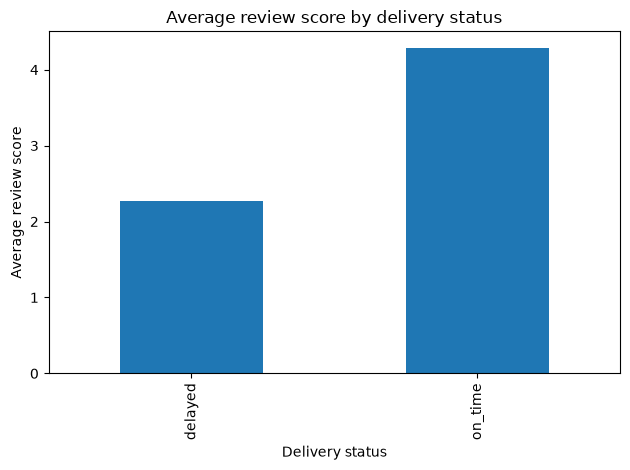

In [41]:
# [1.3-D] 시각화
#
# 힌트
# - kind = "bar"
# - x = "delivery_status"
# - y = "avg_review_score"

ax = delivery_review_df.plot(
    kind="bar",
    x="delivery_status",
    y="avg_review_score",
    legend=False
)

ax.set_title("Average review score by delivery status")
ax.set_xlabel("Delivery status")
ax.set_ylabel("Average review score")
plt.tight_layout()
plt.show()


### 1.3 해석
1. 정상 배송과 지연 배송의 평균 리뷰 점수는 어떻게 달랐는가?
- 정상 배송 주문의 평균 리뷰 점수는 4.29점인 반면 지연 배송 주문의 평균 리뷰 점수는 2.27점으로 낮게 나타났다. 배송이 지연될 경우 고객 만족도 및 리뷰 점수가 현저히 하락함을 알 수 있다.

2. `delay_days`와 `is_delayed`를 둘 다 만든 이유는?
- delay_days 는 실제 지연된 일수, 수치형 연속 변수를 정밀하게 파악하기 위해 생성하였고, is_delayed 는 배송 지연 여부를 기준으로 정시 배송과 지연 배송 그룹 간 비교 분석 및 집계를 용이하게 하기 위해 생성하였다.

3. `order_mart`의 Grain은?
- order_id 기준의 1 row = 1 order 주문 1건당 1행이다. 전체 행 수와 고유 주문 수가 99,441건으로 정확히 일치하여 검증이 완료되었다.

4. 이 결과만으로 배송 지연이 리뷰 하락의 **원인**이라고 말할 수 있는가?
- 상관관계는 명확히 나타나지만 이를 직접적인 인과관계로 단정짓기는 어렵다. 배송 지연 외에도 상품의 파손, 품질 불량, 판매자의 응대 문제 등 다른 원인들이 배송 지연과 동시에 발생하여 리뷰 점수에 영향을 주었을 가능성이 존재하기 때문이다.

5. 추가로 확인하고 싶은 변수는?
- 배송 지연이 리뷰 점수 하락에 미친 순수한 영향력을 검증하기 위해 상품 카테고리, 판매자 평점, 배송 거리, 리뷰 텍스트 내용 등을 추가로 확인해 볼 필요가 있다.




---

## 1.4 재구매 고객은 몇 명인가? — 지표 정의 비교

### 정의 A
모든 주문을 구매로 간주

### 정의 B
`delivered` 주문만 성공한 구매로 간주

### 핵심
- 실제 고객 식별자: `customer_unique_id`
- 고객별 주문 순서: `ROW_NUMBER()`
- 직전 주문일: `LAG()`
- 재구매 고객: 주문 2회 이상


In [42]:
# [1.4-A] 정의 A/B 재구매율 비교
#
# 힌트
# - 두 CTE 모두 customer_unique_id 기준 GROUP BY
# - 정의 B에만 delivered 필터
# - repeat customer는 order_count >= 2

repeat_customer_sql = """
WITH all_orders AS (
    SELECT
        c.customer_unique_id AS customer_unique_id,
        COUNT(*) AS order_count
    FROM olist_orders_dataset AS o
    JOIN olist_customers_dataset AS c
      ON o.customer_id = c.customer_id
    GROUP BY c.customer_unique_id
),

delivered_orders AS (
    SELECT
        c.customer_unique_id AS customer_unique_id,
        COUNT(*) AS order_count
    FROM olist_orders_dataset AS o
    JOIN olist_customers_dataset AS c
      ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)

SELECT
    'all_orders' AS definition,
    COUNT(*) AS customer_count,
    SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) AS repeat_customer_count,
    ROUND(
        100.0 * SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS repeat_customer_rate_pct
FROM all_orders

UNION ALL

SELECT
    'delivered_only' AS definition,
    COUNT(*) AS customer_count,
    SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) AS repeat_customer_count,
    ROUND(
        100.0 * SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS repeat_customer_rate_pct
FROM delivered_orders;
"""

repeat_customer_df = run_sql(repeat_customer_sql)
repeat_customer_df


,definition,customer_count,repeat_customer_count,repeat_customer_rate_pct
0,all_orders,96096,2997.0,3.12
1,delivered_only,93358,2801.0,3.00


In [43]:
# [1.4-B] ROW_NUMBER + LAG
#
# 두 Window Function 모두:
# PARTITION BY customer_unique_id
# ORDER BY order_purchase_timestamp, order_id
#
# order_id를 두 번째 정렬 기준으로 넣는 이유:
# 같은 timestamp가 있어도 순서를 안정적으로 결정하기 위해서입니다.

customer_history_sql = """
WITH ordered_customer_orders AS (
    SELECT
        c.customer_unique_id,
        o.order_id,
        o.order_status,
        o.order_purchase_timestamp,

        ROW_NUMBER() OVER (
            PARTITION BY c.customer_unique_id
            ORDER BY o.order_purchase_timestamp, o.order_id
        ) AS order_number,

        LAG(o.order_purchase_timestamp) OVER (
            PARTITION BY c.customer_unique_id
            ORDER BY o.order_purchase_timestamp, o.order_id
        ) AS previous_order_timestamp

    FROM olist_orders_dataset AS o
    JOIN olist_customers_dataset AS c
      ON o.customer_id = c.customer_id
)

SELECT
    *,
    DATEDIFF(
        order_purchase_timestamp,
        previous_order_timestamp
    ) AS days_since_previous_order

FROM ordered_customer_orders
WHERE previous_order_timestamp IS NOT NULL;
"""

customer_history_df = run_sql(customer_history_sql)
customer_history_df.head()


,customer_unique_id,order_id,order_status,order_purchase_timestamp,order_number,previous_order_timestamp,days_since_previous_order
0,00172711b30d52eea8b313a7f2cced02,c306eca42d32507b970739b5b6a5a33a,canceled,2018-08-13 09:14:07,2,2018-07-28 00:23:49,16
1,004288347e5e88a27ded2bb23747066c,08204559bebd39e09ee52dcb56d8faa2,delivered,2018-01-14 07:36:54,2,2017-07-27 14:13:03,171
2,004b45ec5c64187465168251cd1c9c2f,9392c5e72885ad5aba87e6223ca9838d,delivered,2018-05-26 19:42:48,2,2017-09-01 12:11:23,267
3,0058f300f57d7b93c477a131a59b36c3,81a93b2fa39e104b865b2bc471c16008,delivered,2018-03-22 18:09:41,2,2018-02-19 17:11:34,31
4,00a39521eb40f7012db50455bf083460,cea3e6c11eb60acb9d8d4d51694832f8,delivered,2018-06-03 10:12:57,2,2018-05-23 20:14:21,11


In [44]:
# [1.4-C] 같은 날 발생한 후속 주문 수
#
# 힌트:
# days_since_previous_order == 0 인 행 개수

same_day_repeat_count = (
    customer_history_df["days_since_previous_order"] == 0
).sum()

print("same-day repeat rows:", same_day_repeat_count)


same-day repeat rows: 961


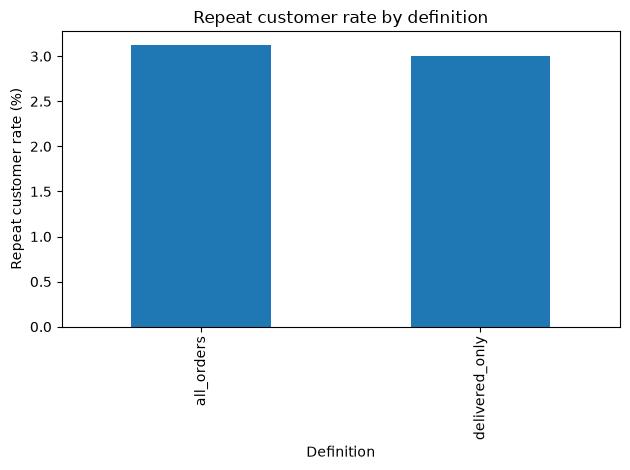

In [45]:
# [1.4-D] 정의 A/B 재구매율 시각화
#
# 힌트:
# kind = "bar"
# x = "definition"
# y = "repeat_customer_rate_pct"

ax = repeat_customer_df.plot(
    kind="bar",
    x="definition",
    y="repeat_customer_rate_pct",
    legend=False
)

ax.set_title("Repeat customer rate by definition")
ax.set_xlabel("Definition")
ax.set_ylabel("Repeat customer rate (%)")
plt.tight_layout()
plt.show()


### 1.4 해석
1. 왜 `customer_id`가 아니라 `customer_unique_id`를 사용해야 하는가?
- Olist 데이터베이스에서 customer_id 는 개별 주문 건마다 새로 생성되는 일회성 주문 식별자이고 customer_unique_id 가 실제 동일한 고객을 식별하는 고유 ID 이기 때문이다. 따라서 고객의 재구매 여부를 집계하기 위해서는 customer_unique_id 를 기준으로 그룹화해야 한다.

2. 정의 A/B의 재구매율이 다른 이유는?
- 모든 주문을 포함한 정의 A, all_orders의 재구매율은 3.12%인 반면, 배송 완료된 주문만 포함한 정의 B, delivered_only의 재구매율은 3.00% 로 나타났다. 취소나 미배송 주문이 제외되면서 성공한 구매 이력만 남았기 때문에 전체 고객 수와 재구매 고객 수가 모두 줄어들어 재구매율 차이가 발생하였다.

3. 본인은 어떤 정의가 더 적절하다고 보는가?
- 배송이 완료되어 실제 매출로 연결된 정의 B, delivered_only 가 더 적절하다고 생각한다. 취소나 환불된 주문까지 재구매 고객으로 간주하는 것은 실질적인 고객 가치를 과대평가할 위험이 있기 때문이다.

4. 같은 날 발생한 후속 주문을 재구매로 볼 것인가?
- 같은 날 발생한 후속 주문 건수는 단시간 내 시스템 오류, 결제 수단 분할 등의 이유로 결제했을 가능성이 높다. 따라서 진정한 시차를 둔 재구매로 보기는 어려우며, 분석 목적에 따라 당일 재주문 건은 단일 구매 세션으로 묶어서 처리하는 것이 타당하다.

5. **SQL보다 지표 정의가 먼저**라는 말의 의미는?
- SQL 쿼리를 작성하는 기술적인 과정보다 어떤 주문 상태를 성공한 구매로 볼 것인지, 재구매의 기준 시점을 어떻게 정의할 것인지 등 분석 목적에 맞는 비즈니스 로직과 지표의 정의를 명확히 세우는 것이 선행되어야 함을 의미한다. 지표 정의가 모호하면 아무리 정교한 SQL 을 작성하더라도 분석 결과의 신뢰성을 확보할 수 없다.



---

## 1.5 월별 매출 변화 + 카테고리 원인 분해

배송 완료 주문 기준, **2017-01 ~ 2018-08** 분석

### 계산
- 월별 매출
- 전월 매출
- 전월 대비 증감액
- MoM 증감률
- 가장 큰 감소 구간
- 해당 구간의 카테고리별 변화


In [46]:
# [1.5-A] 월별 매출 + LAG
#
# 힌트
# - month = DATE_FORMAT(order_purchase_timestamp, '%Y-%m')
# - revenue = SUM(oi.price)
# - order_count = COUNT(DISTINCT o.order_id)
# - customer_count = COUNT(DISTINCT c.customer_unique_id)
# - delivered만 사용
# - 기간: '2017-01-01' 이상, '2018-09-01' 미만
# - previous_revenue = LAG(revenue) OVER (ORDER BY month)

monthly_sales_sql = """
WITH monthly_sales AS (
    SELECT
        DATE_FORMAT(
            o.order_purchase_timestamp,
            '%Y-%m'
        ) AS month,

        SUM(oi.price) AS revenue,
        COUNT(DISTINCT o.order_id) AS order_count,
        COUNT(DISTINCT c.customer_unique_id) AS customer_count

    FROM olist_orders_dataset AS o
    JOIN olist_order_items_dataset AS oi
      ON o.order_id = oi.order_id
    JOIN olist_customers_dataset AS c
      ON o.customer_id = c.customer_id

    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp >= '2017-01-01'
      AND o.order_purchase_timestamp <  '2018-09-01'

    GROUP BY DATE_FORMAT(
        o.order_purchase_timestamp,
        '%Y-%m'
    )
),

monthly_with_previous AS (
    SELECT
        month,
        revenue,
        order_count,
        customer_count,
        LAG(revenue) OVER (
            ORDER BY month
        ) AS previous_revenue
    FROM monthly_sales
)

SELECT
    month,
    ROUND(revenue, 2) AS revenue,
    order_count,
    customer_count,
    ROUND(previous_revenue, 2) AS previous_revenue,

    ROUND(
        revenue - previous_revenue,
        2
    ) AS mom_change,

    ROUND(
        100.0 * (revenue - previous_revenue)
        / NULLIF(previous_revenue, 0),
        2
    ) AS growth_rate_pct

FROM monthly_with_previous
ORDER BY month;
"""

monthly_sales_df = run_sql(monthly_sales_sql)
monthly_sales_df


,month,revenue,order_count,customer_count,previous_revenue,mom_change,growth_rate_pct
0,2017-01,111798.36,750,718,NaN,NaN,NaN
1,2017-02,234223.40,1653,1630,111798.36,122425.04,109.51
2,2017-03,359198.85,2546,2508,234223.40,124975.45,53.36
3,2017-04,340669.68,2303,2274,359198.85,-18529.17,-5.16
4,2017-05,489338.25,3546,3479,340669.68,148668.57,43.64
5,2017-06,421923.37,3135,3076,489338.25,-67414.88,-13.78
6,2017-07,481604.52,3872,3802,421923.37,59681.15,14.15
7,2017-08,554699.70,4193,4114,481604.52,73095.18,15.18
8,2017-09,607399.67,4150,4083,554699.70,52699.97,9.50
9,2017-10,648247.65,4478,4417,607399.67,40847.98,6.73


In [47]:
# [1.5-B] 가장 큰 감소 월
#
# 힌트:
# growth_rate_pct가 가장 작은 행을 찾습니다.

worst_idx = monthly_sales_df["growth_rate_pct"].idxmin()
worst_month = monthly_sales_df.loc[worst_idx]

print(worst_month)


month                 2017-12
revenue             726033.19
order_count              5513
customer_count           5450
previous_revenue    987765.37
mom_change         -261732.18
growth_rate_pct         -26.5
Name: 11, dtype: object


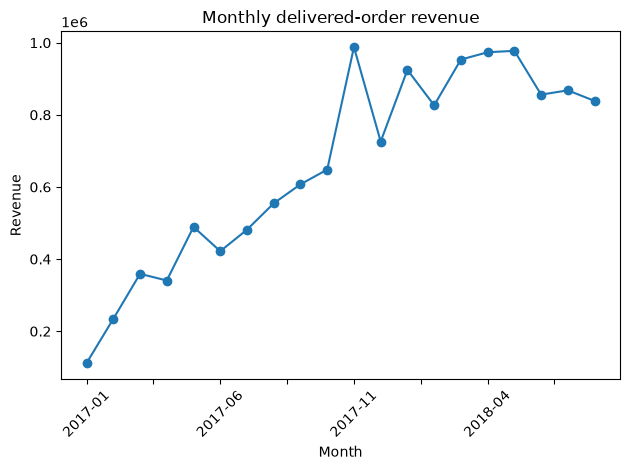

In [48]:
# [1.5-C] 월별 매출 추이
#
# 힌트:
# kind = "line"
# x = "month"
# y = "revenue"

ax = monthly_sales_df.plot(
    kind="line",
    x="month",
    y="revenue",
    marker="o",
    legend=False
)

ax.set_title("Monthly delivered-order revenue")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [49]:
# [1.5-D] 2017-11 vs 2017-12 카테고리별 변화
#
# 힌트
# - 카테고리: 번역명이 있으면 영어명, 없으면 원래 카테고리명
# - revenue = SUM(oi.price)
# - delivered만 사용
# - 기간: '2017-11-01' 이상, '2018-01-01' 미만
# - 11월/12월 매출은 conditional aggregation으로 같은 행에 배치
#
# 주의:
# 카테고리별 단순 LAG는 어떤 달의 데이터가 없으면
# '직전 월'이 아닌 '직전에 존재하는 달'을 비교할 수 있습니다.

category_change_sql = """
WITH category_monthly_sales AS (
    SELECT
        COALESCE(
            tr.product_category_name_english,
            pr.product_category_name,
            'unknown'
        ) AS category,

        DATE_FORMAT(
            o.order_purchase_timestamp,
            '%Y-%m'
        ) AS month,

        SUM(oi.price) AS revenue

    FROM olist_orders_dataset AS o
    JOIN olist_order_items_dataset AS oi
      ON o.order_id = oi.order_id
    JOIN olist_products_dataset AS pr
      ON oi.product_id = pr.product_id
    LEFT JOIN product_category_name_translation AS tr
      ON pr.product_category_name = tr.product_category_name

    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp >= '2017-11-01'
      AND o.order_purchase_timestamp <  '2018-01-01'

    GROUP BY
        COALESCE(
            tr.product_category_name_english,
            pr.product_category_name,
            'unknown'
        ),
        DATE_FORMAT(
            o.order_purchase_timestamp,
            '%Y-%m'
        )
),

category_compare AS (
    SELECT
        category,

        SUM(
            CASE
                WHEN month = '2017-11' THEN revenue
                ELSE 0
            END
        ) AS revenue_2017_11,

        SUM(
            CASE
                WHEN month = '2017-12' THEN revenue
                ELSE 0
            END
        ) AS revenue_2017_12

    FROM category_monthly_sales
    GROUP BY category
)

SELECT
    category,
    ROUND(revenue_2017_11, 2) AS revenue_2017_11,
    ROUND(revenue_2017_12, 2) AS revenue_2017_12,

    ROUND(
        revenue_2017_12 - revenue_2017_11,
        2
    ) AS change_amount

FROM category_compare
ORDER BY change_amount ASC
LIMIT 10;
"""

category_change_df = run_sql(category_change_sql)
category_change_df


,category,revenue_2017_11,revenue_2017_12,change_amount
0,bed_bath_table,87957.63,50081.16,-37876.47
1,computers_accessories,69676.32,37428.67,-32247.65
2,furniture_decor,62091.27,31073.09,-31018.18
3,watches_gifts,95292.34,69556.92,-25735.42
4,cool_stuff,55696.66,37515.57,-18181.09
5,health_beauty,78274.40,60688.75,-17585.65
6,garden_tools,44275.18,26795.69,-17479.49
7,telephony,26117.63,12780.44,-13337.19
8,office_furniture,17919.20,6684.37,-11234.83
9,agro_industry_and_commerce,13932.49,5291.70,-8640.79


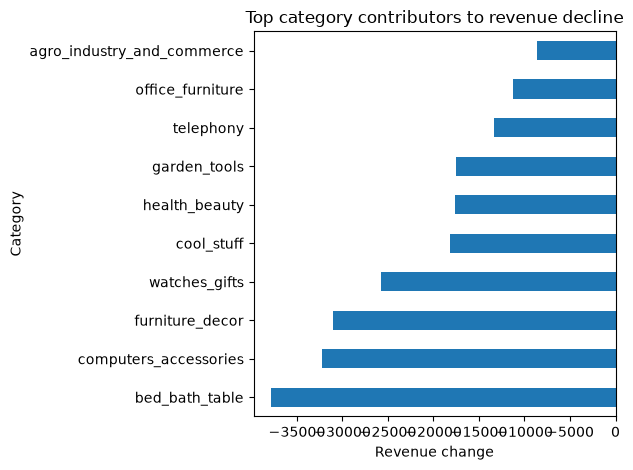

In [50]:
# [1.5-E] 감소 기여 Top 10 그래프
#
# 힌트:
# kind = "barh"
# x = "category"
# y = "change_amount"

plot_df = category_change_df.sort_values("change_amount")

ax = plot_df.plot(
    kind="barh",
    x="category",
    y="change_amount",
    legend=False
)

ax.set_title("Top category contributors to revenue decline")
ax.set_xlabel("Revenue change")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()


### 1.5 해석
1. 가장 큰 매출 감소 시점은?
- 전월 대비 성장률 growth_rate_pct이 -26.50% 로 가장 크게 급감한 2017년 12월 이다.
2. 감소 폭은?
- 전월 대비 매출 감소액 mom_change은 -261732.18이다.
3. 감소에 크게 기여한 카테고리는?
- 12월 매출 감소에 가장 크게 기여한 상위 카테고리는 bed_bath_table, computers_accessories , furniture_decor, watches_gifts 이다.
4. 이 결과만으로 실제 **원인**을 확정할 수 있는가?
- 확정할 수 없다. 제공된 데이터에는 매출 감소 시점의 마케팅 프로모션 유무, 상품 재고 상태, 외부 시장 환경 등의 부가 정보가 포함되어 있지 않다. 단순히 11월에 매출이 급증했다가 12월에 감소한 숫자 변화만 확인될 뿐이므로, 이것이 정상적인 수치 감소인지 데이터 외적인 요인에 의한 것인지 판단하기 어렵다.
5. 추가로 필요한 데이터는?
- 실질적인 원인을 분석하기 위해 전년 동기(2016년 12월) 매출 데이터, 카테고리별 할인율 및 프로모션 진행 이력, 카테고리별 재고 소진 데이터, 마케팅 집행 비용 데이터 등을 추가로 확보하여 분석해야 한다.


# 2. 심화 과제 — 아래 중 1개 선택


### A. 배송
배송 지연이 많은 판매자 또는 카테고리 분석

### B. 고객
1회 구매 고객 vs 2회 이상 구매 고객 평균 주문금액 비교

### C. 매출
매출 변화가 큰 시점을 지역 또는 카테고리 관점에서 분해

### D. 자유 분석
상급자에게 보고할 가치가 있는 질문을 직접 정의


In [51]:
# [심화 과제 B] 1회 구매 고객 vs 2회 이상 구매 고객 지표 비교
#
# 1) 분석 Grain: customer_unique_id (고객 1명당 1행)
# 2) JOIN Key:
#    - olist_orders_dataset.customer_id = olist_customers_dataset.customer_id
#    - olist_orders_dataset.order_id = olist_order_items_dataset.order_id
# 3) 행 수 검증:
#    - base CTE의 customer_unique_id COUNT(DISTINCT) 수와 summary CTE의 전체 행 수가 일치하는지 검증
# 4) 핵심 지표:
#    - avg_customer_spend: 고객 당 평균 총 지출액
#    - avg_order_value (AOV): 평균 1회 주문 금액

deep_dive_sql = """
WITH base AS (
    SELECT
        c.customer_unique_id,
        o.order_id,
        oi.price
    FROM olist_orders_dataset AS o
    JOIN olist_customers_dataset AS c
      ON o.customer_id = c.customer_id
    JOIN olist_order_items_dataset AS oi
      ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
),

customer_summary AS (
    SELECT
        customer_unique_id,
        COUNT(DISTINCT order_id) AS total_orders,
        SUM(price) AS total_spent,
        CASE
            WHEN COUNT(DISTINCT order_id) = 1 THEN '1_time'
            ELSE '2_or_more_times'
        END AS customer_group
    FROM base
    GROUP BY customer_unique_id
),

summary AS (
    SELECT
        customer_group,
        COUNT(customer_unique_id) AS customer_count,
        ROUND(AVG(total_spent), 2) AS avg_customer_spend,
        ROUND(AVG(total_spent / total_orders), 2) AS avg_order_value
    FROM customer_summary
    GROUP BY customer_group
)

SELECT *
FROM summary
ORDER BY customer_group;
"""

deep_dive_df = run_sql(deep_dive_sql)
deep_dive_df

,customer_group,customer_count,avg_customer_spend,avg_order_value
0,1_time,90557,137.96,137.96
1,2_or_more_times,2801,260.05,122.96


In [52]:
# 집계 전/후 행 수 검증
validation_sql = """
SELECT
    (SELECT COUNT(DISTINCT c.customer_unique_id)
     FROM olist_orders_dataset AS o
     JOIN olist_customers_dataset AS c ON o.customer_id = c.customer_id
     WHERE o.order_status = 'delivered') AS unique_customers_before_summary,

    (SELECT COUNT(*)
     FROM (
         SELECT c.customer_unique_id
         FROM olist_orders_dataset AS o
         JOIN olist_customers_dataset AS c ON o.customer_id = c.customer_id
         WHERE o.order_status = 'delivered'
         GROUP BY c.customer_unique_id
     ) AS t) AS unique_customers_after_summary;
"""

validation_df = run_sql(validation_sql)
validation_df

,unique_customers_before_summary,unique_customers_after_summary
0,93358,93358


### 심화 과제 B 작성
- 분석 질문: 1회 구매 고객과 2회 이상 구매한 재구매 고객 간의 고객 당 평균 총 지출액 및 평균 1회 주문 금액에는 어떠한 차이가 있는가?
- 분석 Grain: customer_unique_id
- 사용 테이블: olist_orders_dataset, olist_customers_dataset, olist_order_items_dataset
- JOIN Key:
olist_orders_dataset.customer_id = olist_customers_dataset.customer_id
/ olist_orders_dataset.order_id = olist_order_items_dataset.order_id
- 지표 / 파생변수:

customer_group: 총 주문 건수가 1회인 경우 1_time, 2회 이상인 경우 2_or_more_times 로 분류한 범주형 변수

avg_customer_spend: 고객 그룹별 고객 1명당 평균 총 지출 금액

avg_order_value: 고객 그룹별 주문 1건당 평균 결제 금액
- 필터 기준: order_status = 'delivered'
- 검증 방법: base 단계의 고유 고객 수 COUNT(DISTINCT c.customer_unique_id)와 customer_summary 집계 후 고객 수 COUNT(*)가 93,358명 으로 정확히 일치함을 확인하여 집계 과정에서 데이터 누락이나 중복이 없음을 검증하였다.
- 핵심 숫자 2~3개:

재구매 고객의 평균 총 지출액: 260.05

재구매 고객의 평균 1회 주문 금액: 122.96

분석 대상 전체 고객 수: 93,358명
- 해석:

고객 당 평균 총 지출액이 1회 구매 고객은 137.96 인 반면, 2회 이상 재구매 고객은 260.05 로 재구매 고객이 약 1.88배(122.09 더 높음) 더 많은 금액을 지출하였다.

평균 1회 주문 금액은 1회 구매 고객은 137.96 인 반면, 2회 이상 재구매 고객은 122.96 로 오히려 재구매 고객의 1회당 주문 금액이 약 10.87%(15.00 더 낮음) 낮게 나타났다.

결론적으로 재구매 고객은 여러 번 구매하여 누적 지출액은 훨씬 높지만 1회 주문할 때 쓰는 평균 금액은 1회성 구매 고객보다 다소 낮다.

- 한계 / 추가 분석: 본 분석은 배송비 및 할인 쿠폰 적용 여부를 제외한 Pure Product Price 기준으로 집계되었으므로 실제 고객의 최종 결제 체감 금액과는 다소 차이가 존재할 수 있다.


#### 🤔 회고

Part A에서 겪은 어려움과 해결 과정을 3-5문장으로 적습니다. 끝까지 헷갈린 개념 1-3개도 함께: 1 대 N 관계를 가진 여러 테이블을 사전 집계 없이 JOIN 했을 때 데이터 행 수와 집계 수치가 폭증하는 Row Explosion 현상을 이해하고 올바른 Grain 을 설정하는 데 어려움이 있었다. 이를 해결하기 위해 COUNT(*) 와 COUNT(DISTINCT order_id) 를 비교하여 테이블 간의 카디널리티 관계를 먼저 확인하고, Subquery 와 CTE 를 활용해 1 대 1 관계로 사전 집계 후 JOIN 하는 방식으로 해결하였다. 끝까지 헷갈린 개념은 1 대 N 대 M 다중 JOIN 시 발생하는 중복 행 증폭의 정확한 계산 구조, SELECT DISTINCT 가 SUM 연산의 데이터 증폭을 막아주지 못하는 내부 동작 원리이다.

Part B(심화 선택)를 진행했다면, 새롭게 알게 된 점을 이어서 적어도 좋습니다: 재구매 고객의 누적 지출액은 1회 구매 고객보다 약 1.88배 높지만, 1회당 평균 주문 금액은 오히려 약 10.87% 낮다는 점을 새롭게 알게 되었다.

#### ⚙️ 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): Colab 로컬 런타임 연결 환경 설정 오류(Jupyter Notebook 로컬 구동, CMD 실행 유지 여부, 127.0.0.1 및 localhost 토큰 주소 개념 해석), SQL 빈칸 채우기 정답 검증, Row Explosion 개념 및 발생 이유 해설 작성, ROW_NUMBER 와 LAG 윈도우 함수를 활용한 재구매 고객 집계 쿼리 구문 작성에 활용하였다.

- **AI가 이 실험에는 틀린 답을 준 사례**
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요:  
  Colab 을 로컬 런타임에 연결하는 과정에서 http://localhost:8888/?token=... 주소를 입력했으나 지속적으로 연결 오류가 발생하였다. AI 에 해결책을 문의하자 "보안 및 CORS 정책 문제일 수 있으니 주피터 웹 화면에서 토큰값을 다시 확인하여 붙여넣으라" 는 일반적인 답변만을 반복해서 제시하였다. 이를 직접 실험해보는 과정에서 주소의 localhost 부분을 Loopback IP 인 127.0.0.1 로 바꾸어 [http://127.0.0.1:8888/?token=](http://127.0.0.1:8888/?token=)... 형태로 입력하자 곧바로 정상 연결됨을 확인하였다. DNS과정에서 localhost 가 IPv6 주소로 먼저 매핑되어 발생한 연결 차단 문제임을 직접 실험을 통해 알아채고 주소를 IP 형태로 교정하여 해결하였다.

- **실제 대화 내역** 붙여넣기:

```
User: Colab 에서 로컬 런타임 연결하려는데 왜 계속 연결 오류가 나?
AI: 주피터 서버가 정상 구동 중인지 확인하시고, 토큰값이 올바른지 웹 화면에서 다시 복사하여 붙여넣어 보시기 바랍니다. 보안이나 CORS 정책 문제일 수 있습니다.

User: 기존 CMD 창은 그냥 닫으면 돼?  이 토큰 링크는 뭐야?
AI: 아니요, CMD 창을 닫으면 로컬 주피터 서버 구동이 중단되어 Colab 연결이 끊기므로 닫으시면 안 됩니다. 링크 뒤의 토큰은 Colab 이 내 컴퓨터로 안전하게 접속할 수 있게 검증하는 일회용 보안 비밀키입니다.
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은 무엇이었나요?
AI 가 안내하는 단편적인 지침이나 코드 가이드를 무조건 수용하지 않고, 로컬 커널 세션의 실제 동작 여부를 터미널에서 직접 실행 및 검증하며 환경적 판단을 내린 점이다.